In [1]:
# 데이터 로드
from sklearn.datasets import fetch_openml
mnist=fetch_openml('mnist_784', version=1)

In [2]:
# train, test split
X_train = mnist['data'][:60000]
y_train = mnist['target'][:60000]
X_test = mnist['data'][60000:]
y_test = mnist['target'][60000:]

* 랜덤포레스트에 적용

In [3]:
from sklearn.ensemble import RandomForestClassifier

# 랜덤포레스트에 적용 (n_estimators=10, random_state=42)
rf_clf = RandomForestClassifier(n_estimators=10, random_state=42)
rf_clf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=10, random_state=42)

In [5]:
from sklearn.metrics import accuracy_score

y_train_pred = rf_clf.predict(X_train)
print(f"훈련 세트 정확도: {accuracy_score(y_train, y_train_pred):.4f}")

y_test_pred = rf_clf.predict(X_test)
print(f"테스트 세트 정확도: {accuracy_score(y_test, y_test_pred):.4f}")

훈련 세트 정확도: 0.9992
테스트 세트 정확도: 0.9492


# 1. PCA

* PCA로 변환한 데이터 세트에 랜덤 포레스트 적용

In [6]:
from sklearn.decomposition import PCA

In [7]:
# PCA 적용 95% : n_components=0.95
pca = PCA(n_components=0.95)
X_train_reduced = pca.fit_transform(X_train)
print(f"Original X_train shape: {X_train.shape}")
print(f"Reduced X_train shape: {X_train_reduced.shape}")

Original X_train shape: (60000, 784)
Reduced X_train shape: (60000, 154)


In [8]:
rf_clf_pca = RandomForestClassifier(n_estimators=10, random_state=42)
rf_clf_pca.fit(X_train_reduced, y_train)

RandomForestClassifier(n_estimators=10, random_state=42)

In [10]:
# 정확도 결과 (X_test도 PCA 적용해야합니다.)
X_test_reduced = pca.transform(X_test)

y_test_pred = rf_clf_pca.predict(X_test_reduced)
print(f"테스트 세트 정확도: {accuracy_score(y_test, y_test_pred):.4f}")

테스트 세트 정확도: 0.8925


**관련 문제**

* PCA모델을 와인 데이터셋에 적용하여 차원을 축소하고 그 결과를 그래프로 나타내보세요.

(1) 필요한 모듈 불러오기

In [11]:
from sklearn.datasets import load_wine
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

(2)  load_wine을 사용해 데이터셋을 생성한다.

In [12]:
load_wine = load_wine()
X = load_wine.data
y = load_wine.target

(3) X에 표준 스케일링(Standard scaling)을 적용하여 X_scaled을 생성한다.

In [13]:
X_scaled = StandardScaler().fit_transform(X)

(4) PCA 모델을 X에 적용하여 2개의 차원으로 추출한다. 단, random_state=1234로 설정한다.

In [14]:
#PCA 모델을 X_scaled에 적용하여 2개의 차원으로 추출한다.

pca = PCA(n_components=2, random_state=1234)
pca.fit(X_scaled)
X_pca = pca.transform(X_scaled)

In [19]:
X_pca.shape

(178, 2)

(5) 추출한 피처를 그래프로 나타내라.

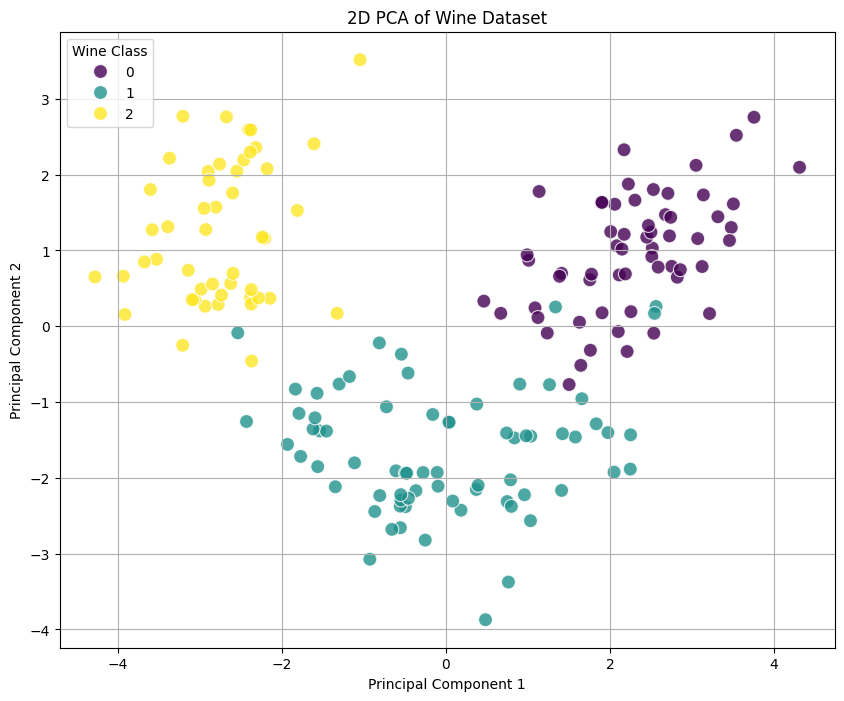

In [20]:
# 추출한 피처를 그래프로 나타내라

# Create a DataFrame for easier plotting
df_pca = pd.DataFrame(data=X_pca, columns=['principal_component_1', 'principal_component_2'])
df_pca['target'] = y

# Visualize the PCA-transformed data
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='principal_component_1',
    y='principal_component_2',
    hue='target',
    data=df_pca,
    palette='viridis',
    s=100, # size of points
    alpha=0.8 # transparency
)
plt.title('2D PCA of Wine Dataset')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.legend(title='Wine Class')
plt.show()

# 2. LDA

- LDA로 변환한 데이터 세트에 랜덤 포레스트 적용

In [21]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

In [22]:
# LDA 적용 : n_components=2 (3개의 클래스를 가지므로 최대 n_components는 2)
lda = LinearDiscriminantAnalysis(n_components=2)
lda.fit(X_scaled, y)
X_lda = lda.transform(X_scaled)
print(f"Original X_scaled shape: {X_scaled.shape}")
print(f"Reduced X_lda shape: {X_lda.shape}")

Original X_scaled shape: (178, 13)
Reduced X_lda shape: (178, 2)


In [24]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# LDA 이후 랜덤포레스트 훈련
# For evaluation, we should split the data into training and testing sets *after* LDA transformation
X_train_lda, X_test_lda, y_train_lda, y_test_lda = train_test_split(X_lda, y, test_size=0.3, random_state=42)

rf_clf_lda = RandomForestClassifier(n_estimators=10, random_state=42)
rf_clf_lda.fit(X_train_lda, y_train_lda)

RandomForestClassifier(n_estimators=10, random_state=42)

In [25]:
from sklearn.metrics import accuracy_score

y_test_pred_lda = rf_clf_lda.predict(X_test_lda)
print(f"테스트 세트 정확도 (LDA): {accuracy_score(y_test_lda, y_test_pred_lda):.4f}")

테스트 세트 정확도 (LDA): 0.9815
